# Import


In [1]:
import os

import numpy as np      
import pandas as pd                  
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow.keras as keras  
import cv2 as cv                     

2026-03-23 19:58:14.077729: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-23 19:58:14.079957: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-23 19:58:14.119498: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-23 19:58:14.119607: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-23 19:58:14.119685: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

## Hilfsfunktionen


In [2]:
def transform_image(img, shift_x=0, shift_y=0, angle=0):
    h, w = img.shape
    M_shift = np.float32([[1, 0, shift_x],
                          [0, 1, shift_y]])
    shifted = cv.warpAffine(img, M_shift, (w, h))

    M_rot = cv.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    transformed = cv.warpAffine(shifted, M_rot, (w, h))

    return transformed


def augment_dataset(x, y, shift_x=3, shift_y=3, angle=15):
    augmented_imgs   = []
    augmented_labels = []

    for img, label in zip(x, y):
        variants = [
            transform_image(img, shift_x= shift_x, shift_y=0,        angle=0),
            transform_image(img, shift_x=-shift_x, shift_y=0,        angle=0),
            transform_image(img, shift_x=0,        shift_y= shift_y, angle=0),
            transform_image(img, shift_x=0,        shift_y=-shift_y, angle=0),
            transform_image(img, shift_x=0,        shift_y=0,        angle= angle),
            transform_image(img, shift_x=0,        shift_y=0,        angle=-angle),
        ]
        augmented_imgs.extend(variants)
        augmented_labels.extend([label] * len(variants))

    x_aug = np.array(augmented_imgs, dtype=x.dtype)
    y_aug = np.array(augmented_labels, dtype=y.dtype)

    return np.concatenate([x, x_aug]), np.concatenate([y, y_aug])


# 1. Daten laden und erkunden


Training Datenformat x: (60000, 28, 28)
Training Datenformat y: (60000,)
Training Datentyp x:        uint8
Training Datentyp y:        uint8
Training Werte y:           [0 1 2 3 4 5 6 7 8 9]
-------------------------------
Test Datenformat x:     (10000, 28, 28)
Test Datenformat y:     (10000,)
Test Datentyp x:        uint8
Test Datentyp y:        uint8
Test Werte y:           [0 1 2 3 4 5 6 7 8 9]


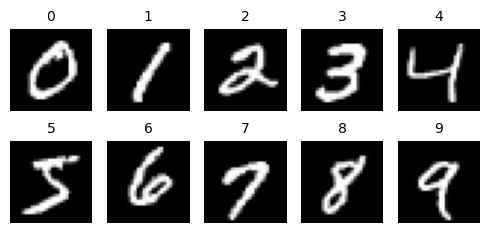

In [3]:

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training Datenformat x: {x_train.shape}")
print(f"Training Datenformat y: {y_train.shape}")
print(f"Training Datentyp x:        {x_train.dtype}")
print(f"Training Datentyp y:        {y_train.dtype}")
print(f"Training Werte y:           {np.unique(y_train)}")
print("-------------------------------")
print(f"Test Datenformat x:     {x_test.shape}")
print(f"Test Datenformat y:     {y_test.shape}")
print(f"Test Datentyp x:        {x_test.dtype}")
print(f"Test Datentyp y:        {y_test.dtype}")
print(f"Test Werte y:           {np.unique(y_test)}")

fig, axes = plt.subplots(2, 5, figsize=(5,2.5))

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    ax = axes[digit // 5, digit % 5]
    ax.imshow(x_train[idx], cmap="gray")
    ax.set_title(str(digit), fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


Der Datensatz besteht aus 60.000 Trainings- und 10.000 Testdatensätzen.
Jeder Datensatz repräsentiert eine Ziffer (0–9) als 28×28 Pixelraster.


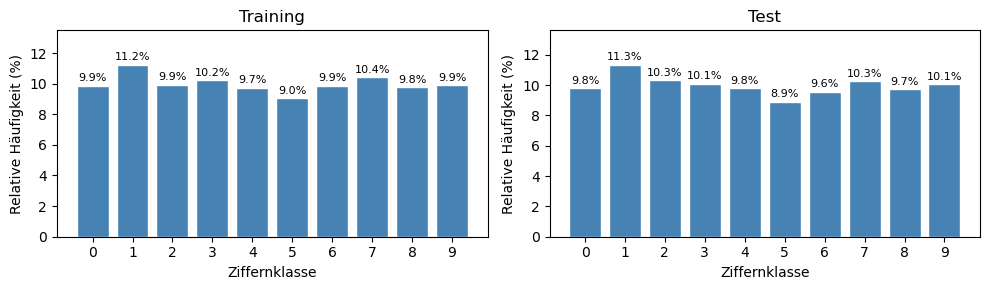

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

datasets = [
    (y_train, "Training"),
    (y_test,  "Test"),
]

for ax, (labels, title) in zip(axes, datasets):
    counts = np.bincount(labels, minlength=10)
    rel = counts / counts.sum()
    rel_pct = rel * 100
    classes = np.arange(10)

    bars = ax.bar(classes, rel_pct, color="steelblue", edgecolor="white")
    ax.set_xticks(classes)
    ax.set_xticklabels(classes)
    ax.set_xlabel("Ziffernklasse")
    ax.set_ylabel("Relative Häufigkeit (%)")
    ax.set_title(title)

    ax.set_ylim(0, rel_pct.max() * 1.20)

    for bar, pct in zip(bars, rel_pct):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.15,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()


Die Klassen sind gleichmäßig verteilt (~10 % pro Klasse).


# 2. Daten vorbereieten

Pixelwerte liegen in [0, 255] und werden von `uint8` zu `float32` konvertiert.
Mithilfe von Bildtransformationen werden mehrere leicht unterschiedliche Varianten der Datensätze simuliert.
Dieser Schritt ist auch als Daten Augmentation bekannt. Dadurch stehen nun zwei Datensätze zur Verfügung (Original vs Augmentiert).


In [5]:
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

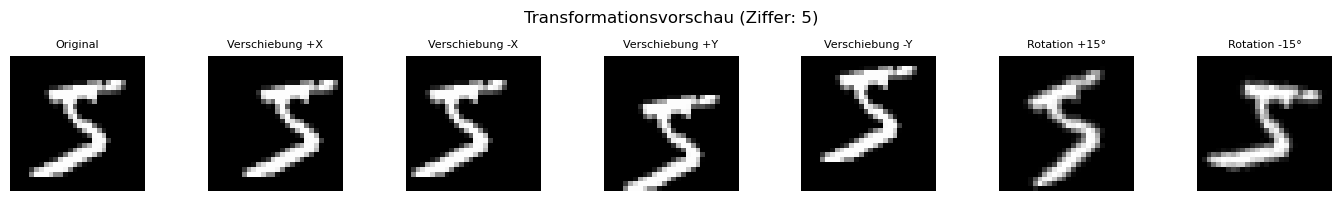

In [6]:

sample_img   = x_train[0]
sample_label = y_train[0]

variants = {
    "Original":         sample_img,
    "Verschiebung +X":         transform_image(sample_img, shift_x= 3),
    "Verschiebung -X":         transform_image(sample_img, shift_x=-3),
    "Verschiebung +Y":         transform_image(sample_img, shift_y= 3),
    "Verschiebung -Y":         transform_image(sample_img, shift_y=-3),
    "Rotation +15°":      transform_image(sample_img, angle= 15),
    "Rotation -15°":      transform_image(sample_img, angle=-15),
}

fig, axes = plt.subplots(1, len(variants), figsize=(14, 2))
fig.suptitle(f"Transformationsvorschau (Ziffer: {sample_label})", fontsize=12)
for ax, (title, img) in zip(axes, variants.items()):
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
x_train_aug, y_train_aug = augment_dataset(x_train, y_train, shift_x=3, shift_y=3, angle=15)

print(f"Ursprüngliche Anzahl Datensätze: {x_train.shape[0]}")
print(f"Augmentierte Anzahl Datensätze: {x_train_aug.shape[0]}")

Ursprüngliche Anzahl Datensätze: 60000
Augmentierte Anzahl Datensätze: 420000


## Normalisieren

Werte werden auf auf den Intervall [0,1] und [-1,1] skaliert


In [8]:
normalized_0_1_x_train = x_train / 255.0
normalized_0_1_x_test  = x_test / 255.0

print(f"Intervall Training: [{normalized_0_1_x_train.min()}, {normalized_0_1_x_train.max()}]")
print(f"Intervall Test: [{normalized_0_1_x_test.min()},  {normalized_0_1_x_test.max()}]")

aug_normalized_0_1_x_train = x_train_aug / 255.0
aug_normalized_0_1_x_test  = normalized_0_1_x_test

Intervall Training: [0.0, 1.0]
Intervall Test: [0.0,  1.0]


In [9]:
normalized_minus1_1_x_train = (x_train / 127.5) - 1.0
normalized_minus1_1_x_test  = (x_test / 127.5) - 1.0

print(f"Intervall Training: [{normalized_minus1_1_x_train.min()}, {normalized_minus1_1_x_train.max()}]")
print(f"Intervall Test: [{normalized_minus1_1_x_test.min()},  {normalized_minus1_1_x_test.max()}]")

aug_normalized_minus1_1_x_train = (x_train_aug / 127.5) - 1.0
aug_normalized_minus1_1_x_test  = normalized_minus1_1_x_test

Intervall Training: [-1.0, 1.0]
Intervall Test: [-1.0,  1.0]


## Standardisieren (z-Score)

Mittelwert 0, Standardabweichung 1 — angewendet auf die normalisierten (0-1) Werte.


In [10]:
std01_mean = normalized_0_1_x_train.mean()
std01_std  = normalized_0_1_x_train.std()

standardized_0_1_x_train = (normalized_0_1_x_train - std01_mean) / std01_std
standardized_0_1_x_test  = (normalized_0_1_x_test  - std01_mean) / std01_std

print(f"Intervall Training: [{standardized_0_1_x_train.min():.3f}, {standardized_0_1_x_train.max():.3f}]")
print(f"Intervall Test:  [{standardized_0_1_x_test.min():.3f},  {standardized_0_1_x_test.max():.3f}]")

aug_standardized_0_1_x_train = (aug_normalized_0_1_x_train - std01_mean) / std01_std
aug_standardized_0_1_x_test  = standardized_0_1_x_test

Intervall Training: [-0.424, 2.822]
Intervall Test:  [-0.424,  2.822]


`np.newaxis` erweitert die Bilder von (28, 28) auf (28, 28, 1) für den Graustufen-Kanal der CNN-Eingabe.

Die vier Varianten werden als `preprocessing_variants` gebündelt und in **Phase 2** verglichen.
Die augmentierten Rohdaten (`x_train_aug`) werden in **Phase 5** erst dann angewendet, wenn die beste Variante bekannt ist.


In [11]:
preprocessing_variants = {
    "Unverändert":                 (x_train[..., np.newaxis],                     y_train, x_test[..., np.newaxis],                     y_test),
    "Normalisiert (0-1)":    (normalized_0_1_x_train[..., np.newaxis],      y_train, normalized_0_1_x_test[..., np.newaxis],      y_test),
    "Normalisiert (-1 bis 1)":(normalized_minus1_1_x_train[..., np.newaxis], y_train, normalized_minus1_1_x_test[..., np.newaxis], y_test),
    "Standardisiert (0-1)":  (standardized_0_1_x_train[..., np.newaxis],    y_train, standardized_0_1_x_test[..., np.newaxis],    y_test),
}

aug_preprocessing_map = {
    "Unverändert":                 x_train_aug[..., np.newaxis],
    "Normalisiert (0-1)":    aug_normalized_0_1_x_train[..., np.newaxis],
    "Normalisiert (-1 bis 1)":aug_normalized_minus1_1_x_train[..., np.newaxis],
    "Standardisiert (0-1)":  aug_standardized_0_1_x_train[..., np.newaxis],
}

print("Vorverarbeitungsvarianten:", list(preprocessing_variants.keys()))
print("Augmentierte Vorverarbeitungsvarianten:", list(aug_preprocessing_map.keys()))


Vorverarbeitungsvarianten: ['Unverändert', 'Normalisiert (0-1)', 'Normalisiert (-1 bis 1)', 'Standardisiert (0-1)']
Augmentierte Vorverarbeitungsvarianten: ['Unverändert', 'Normalisiert (0-1)', 'Normalisiert (-1 bis 1)', 'Standardisiert (0-1)']


# 3. CNN erstellen und Training definieren


In [12]:
results_list = []

checkpoint_dir = "checkpoints"
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)


def create_cnn_model(add_dropout=False, dropout_rate=0.0, blocks=1):
    tf.keras.backend.clear_session()

    basic_layers = [keras.layers.Input(shape=(28, 28, 1))]
    for b in range(blocks):
        basic_layers += [
            keras.layers.Conv2D(filters=(b + 1) * 32, kernel_size=(3, 3), activation="relu"),
            keras.layers.MaxPooling2D(pool_size=(2, 2)),
        ]
    basic_layers += [keras.layers.Flatten()]

    dense_layers = [
        keras.layers.Dense(units=64, activation="relu"),
        *([keras.layers.Dropout(rate=dropout_rate)] if add_dropout else []),
        keras.layers.Dense(units=10, activation="softmax"),
    ]

    model = keras.Sequential(basic_layers + dense_layers, name="simple_cnn")
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_and_evaluate_models(
    datasets, method, batch_size=32, epochs=10, add_dropout=False,
    dropout_rate=0.0, blocks=1, early_stop=False,
):
    results   = []
    histories = {}
    callbacks = []
    if early_stop:
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=5, restore_best_weights=True
            )
        )

    for dataset_name, (data_x_train, data_y_train, data_x_test, data_y_test) in datasets.items():
        print(f"  Training: {dataset_name}")
        model = create_cnn_model(add_dropout=add_dropout, dropout_rate=dropout_rate, blocks=blocks)

        history = model.fit(
            data_x_train, data_y_train,
            batch_size=batch_size, epochs=epochs,
            validation_split=0.2, verbose=0,
            callbacks=callbacks,
        )
        test_loss, test_acc = model.evaluate(data_x_test, data_y_test, verbose=0)

        model_name = (
            f"model_{method.replace(' ', '_')}_"
            f"{dataset_name.replace(' ', '_')}.keras"
        )
        model.save(f"checkpoints/{model_name}")
        histories[dataset_name] = history

        results.append({
            "method":           method,
            "dataset":          dataset_name,
            "test_loss":        float(test_loss),
            "test_acc":         float(test_acc),
            "trained_epochs":   len(history.history["loss"]),
            "best_epoch":       int(np.argmin(history.history["val_loss"]) + 1),
            "batch_size":       batch_size,
            "add_dropout":      add_dropout,
            "dropout_rate":     dropout_rate,
            "blocks":           blocks,
            "early_stop":       early_stop,
            "model_name":       model_name,
        })

    results_df = pd.DataFrame(results).sort_values("test_acc", ascending=False)
    results_list.append(results_df)
    return results_df, histories


def plot_metric_distribution_by_group(
    results_df,
    metric_col="test_acc",
    group_col="blocks",
    x_label_rotation=0,
    ylim=None,
):
    df_plot = results_df[[group_col, metric_col]].dropna().copy()
    df_plot[group_col] = df_plot[group_col].astype(str)
    df_plot = df_plot.sort_values(metric_col, ascending=True)

    labels = df_plot[group_col].tolist()
    values = df_plot[metric_col].tolist()
    best_val = max(values)

    colors = ["steelblue" if v < best_val else "seagreen" for v in values]

    fig, ax = plt.subplots(figsize=(8, max(3, len(labels) * 0.7)))
    bars = ax.barh(labels, values, color=colors, edgecolor="white", height=0.5)

    x_min = min(values) - 0.005 if ylim is None else ylim[0]
    x_max = 1.0 if ylim is None else ylim[1]
    ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.12)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + (x_max - x_min) * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            va="center", ha="left", fontsize=9,
        )

    ax.set_xlabel(metric_col)
    ax.set_ylabel(group_col)
    ax.set_title(f"{metric_col} by {group_col}")
    ax.tick_params(axis="x", labelrotation=x_label_rotation)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_learning_curves(histories, title="Learning Curves"):
    n = len(histories)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)
    for ax, (name, hist) in zip(axes[0], histories.items()):
        ep = range(1, len(hist.history["loss"]) + 1)
        ax.plot(ep, hist.history["accuracy"],     label="Train Acc")
        ax.plot(ep, hist.history["val_accuracy"], label="Val Acc")
        ax.plot(ep, hist.history["loss"],         label="Train Loss", linestyle="--")
        ax.plot(ep, hist.history["val_loss"],     label="Val Loss",   linestyle="--")
        ax.set_title(name, fontsize=10)
        ax.set_xlabel("Epoch")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


---

# Phase 1 – Baseline

Ein einfaches Modell (1 Block, kein Dropout, Rohdaten, 10 Epochen) als Referenzpunkt.
Alle folgenden Phasen versuchen, diese Genauigkeit schrittweise zu übertreffen.


In [13]:
baseline_results, _ = train_and_evaluate_models(
    {"Unverändert": preprocessing_variants["Unverändert"]},
    method="Baseline", batch_size=32, epochs=10, blocks=1,
)

baseline_acc = baseline_results.iloc[0]["test_acc"]
print(f"\n→ Baseline accuracy (Unverändert, 1 Block, kein Dropout): {baseline_acc:.4f}")

  Training: Unverändert


2026-03-23 19:58:33.647947: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-23 19:58:33.714604: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



→ Baseline accuracy (Unverändert, 1 Block, kein Dropout): 0.9775


In [14]:
baseline_16_results, _ = train_and_evaluate_models(
    {"Unverändert": preprocessing_variants["Unverändert"]},
    method="Baseline", batch_size=16, epochs=10, blocks=1,
)

baseline_64_results, _ = train_and_evaluate_models(
    {"Unverändert": preprocessing_variants["Unverändert"]},
    method="Baseline", batch_size=64, epochs=10, blocks=1,
)

baseline_128_results, _ = train_and_evaluate_models(
    {"Unverändert": preprocessing_variants["Unverändert"]},
    method="Baseline", batch_size=128, epochs=10, blocks=1,
)

baseline_batch_size_results = pd.concat([baseline_16_results, baseline_results, baseline_64_results, baseline_128_results], ignore_index=True)
best_batch_size = baseline_batch_size_results.loc[baseline_batch_size_results["test_acc"].idxmax(), "batch_size"]
best_batch_size_acc = baseline_batch_size_results["test_acc"].max()
print(f"\n→ Beste Batch Size: {best_batch_size} (Accuracy: {best_batch_size_acc:.4f}), Verbesserung zu Baseline %: {(best_batch_size_acc - baseline_acc) / baseline_acc * 100:.2f}%")
baseline_batch_size_results

  Training: Unverändert


  Training: Unverändert
  Training: Unverändert

→ Beste Batch Size: 128 (Accuracy: 0.9798), Verbesserung zu Baseline %: 0.24%


,method,dataset,test_loss,test_acc,trained_epochs,best_epoch,batch_size,add_dropout,dropout_rate,blocks,early_stop,model_name
0,Baseline,Unverändert,0.151147,0.9747,10,3,16,False,0.0,1,False,model_Baseline_Unverändert.keras
1,Baseline,Unverändert,0.143667,0.9775,10,6,32,False,0.0,1,False,model_Baseline_Unverändert.keras
2,Baseline,Unverändert,0.108592,0.9785,10,3,64,False,0.0,1,False,model_Baseline_Unverändert.keras
3,Baseline,Unverändert,0.101792,0.9798,10,4,128,False,0.0,1,False,model_Baseline_Unverändert.keras


---

# Phase 2 – Beste Vorverarbeitung finden

Selbe Architektur wie in Phase 1 (1 Block, kein Dropout, 10 Epochen) auf allen vier Varianten.
Das Ergebnis bestimmt die Vorverarbeitung für **alle** weiteren Phasen.


In [15]:
print("Trainiere alle Vorverarbeitungsvarianten...")
phase2_results, _ = train_and_evaluate_models(
    preprocessing_variants,
    method="Preprocessing", batch_size=best_batch_size, epochs=10, blocks=1,
)
phase2_results


Trainiere alle Vorverarbeitungsvarianten...
  Training: Unverändert
  Training: Normalisiert (0-1)
  Training: Normalisiert (-1 bis 1)
  Training: Standardisiert (0-1)


,method,dataset,test_loss,test_acc,trained_epochs,best_epoch,batch_size,add_dropout,dropout_rate,blocks,early_stop,model_name
3,Preprocessing,Standardisiert (0-1),0.057855,0.9840,10,4,128,False,0.0,1,False,model_Preprocessing_Standardisiert_(0-1).keras
1,Preprocessing,Normalisiert (0-1),0.054185,0.9836,10,7,128,False,0.0,1,False,model_Preprocessing_Normalisiert_(0-1).keras
2,Preprocessing,Normalisiert (-1 bis 1),0.060066,0.9824,10,6,128,False,0.0,1,False,model_Preprocessing_Normalisiert_(-1_bis_1).keras
0,Preprocessing,Unverändert,0.124632,0.9736,10,5,128,False,0.0,1,False,model_Preprocessing_Unverändert.keras


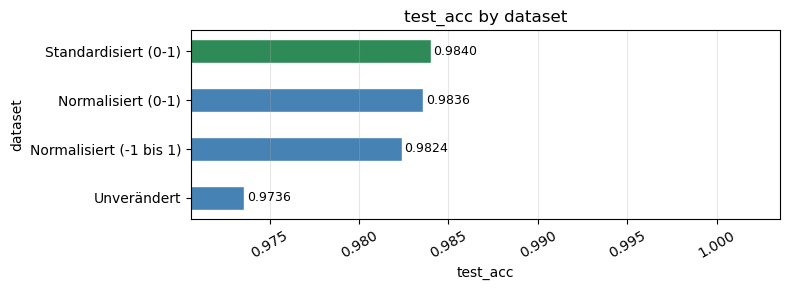

→ Beste Vorverarbeitung: 'Standardisiert (0-1)'  (Accuracy: 0.9840, Verbesserung zu Baseline %: 0.66%)


In [16]:
plot_metric_distribution_by_group(
    phase2_results, metric_col="test_acc", group_col="dataset",
    x_label_rotation=30,
    ylim=(phase2_results["test_acc"].min() - 0.003, 1.0),
)

best_preprocessing = phase2_results.iloc[0]["dataset"]
best_preprocessing_acc = phase2_results.iloc[0]["test_acc"]

print(f"→ Beste Vorverarbeitung: '{best_preprocessing}'  (Accuracy: {best_preprocessing_acc:.4f}, Verbesserung zu Baseline %: {(best_preprocessing_acc - baseline_acc) / baseline_acc * 100:.2f}%)")


---

# Phase 3 – Beste Architektur finden (Anzahl der Blöcke)

Beste Vorverarbeitung aus Phase 2, kein Dropout, 10 Epochen.
Verglichen werden 1, 2 und 3 Convolutional Blocks.
Das Ergebnis bestimmt die Blockanzahl für alle weiteren Phasen.


Trainiere Blockanzahl-Varianten mit Vorverarbeitung: 'Standardisiert (0-1)'...
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)


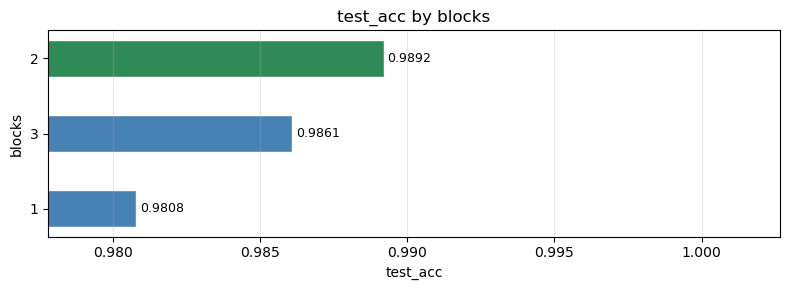


→ Beste Blockanzahl: 2 (Accuracy: 0.9892), Verbesserung zu Baseline %: 1.20%)


,method,dataset,test_loss,test_acc,trained_epochs,best_epoch,batch_size,add_dropout,dropout_rate,blocks,early_stop,model_name
0,Architecture,Standardisiert (0-1),0.067084,0.9808,10,5,128,False,0.0,1,False,model_Architecture_Standardisiert_(0-1).keras
1,Architecture,Standardisiert (0-1),0.038104,0.9892,10,8,128,False,0.0,2,False,model_Architecture_Standardisiert_(0-1).keras
2,Architecture,Standardisiert (0-1),0.052884,0.9861,10,5,128,False,0.0,3,False,model_Architecture_Standardisiert_(0-1).keras


In [17]:
print(f"Trainiere Blockanzahl-Varianten mit Vorverarbeitung: '{best_preprocessing}'...")
phase3_results = pd.concat(
    [
        train_and_evaluate_models(
            {best_preprocessing: preprocessing_variants[best_preprocessing]},
            method="Architecture", batch_size=best_batch_size, epochs=10, blocks=b,
        )[0]
        for b in [1, 2, 3]
    ],
    ignore_index=True,
)

plot_metric_distribution_by_group(
    phase3_results, metric_col="test_acc", group_col="blocks",
    ylim=(phase3_results["test_acc"].min() - 0.003, 1.0),
)

best_blocks = int(phase3_results.loc[phase3_results["test_acc"].idxmax(), "blocks"])
best_blocks_acc = phase3_results["test_acc"].max()
print(f"\n→ Beste Blockanzahl: {best_blocks} (Accuracy: {best_blocks_acc:.4f}), Verbesserung zu Baseline %: {(best_blocks_acc - baseline_acc) / baseline_acc * 100:.2f}%)")
phase3_results


---

# Phase 4 – Beste Regularisierung finden (Dropout)

Beste Vorverarbeitung + beste Blockanzahl aus Phase 3, mit Early Stopping (Patience 5, max. 100 Epochen).
Verglichen werden Dropout-Raten: 0.1, 0.2 und 0.5.
Das Ergebnis bestimmt die Dropout-Rate für Phase 5 und das Ensemble.


  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)


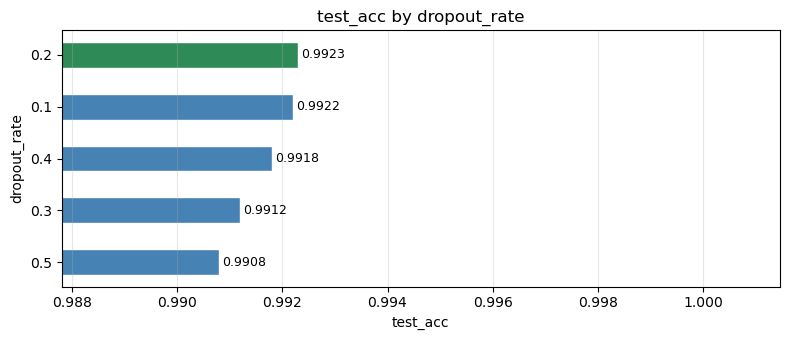


→ Beste Dropout-Rate: 0.2  (Accuracy: 0.9923, Verbesserung zu Baseline %: 1.51%)


,method,dataset,test_loss,test_acc,trained_epochs,best_epoch,batch_size,add_dropout,dropout_rate,blocks,early_stop,model_name
0,Dropout,Standardisiert (0-1),0.028485,0.9922,10,8,128,True,0.1,2,False,model_Dropout_Standardisiert_(0-1).keras
1,Dropout,Standardisiert (0-1),0.027813,0.9923,10,10,128,True,0.2,2,False,model_Dropout_Standardisiert_(0-1).keras
2,Dropout,Standardisiert (0-1),0.027181,0.9912,10,8,128,True,0.3,2,False,model_Dropout_Standardisiert_(0-1).keras
3,Dropout,Standardisiert (0-1),0.026714,0.9918,10,6,128,True,0.4,2,False,model_Dropout_Standardisiert_(0-1).keras
4,Dropout,Standardisiert (0-1),0.032375,0.9908,10,7,128,True,0.5,2,False,model_Dropout_Standardisiert_(0-1).keras


In [18]:
phase4_parts    = []
phase4_histories = {}

for rate in [0.1, 0.2, 0.3, 0.4, 0.5]:
    df, hist = train_and_evaluate_models(
        {best_preprocessing: preprocessing_variants[best_preprocessing]},
        method="Dropout", batch_size=best_batch_size, epochs=10,
        add_dropout=True, dropout_rate=rate, blocks=best_blocks,
    )
    phase4_parts.append(df)
    phase4_histories[f"Dropout {rate}"] = hist[best_preprocessing]

phase4_results = pd.concat(phase4_parts, ignore_index=True)

plot_metric_distribution_by_group(
    phase4_results, metric_col="test_acc", group_col="dropout_rate",
    ylim=(phase4_results["test_acc"].min() - 0.003, 1.0),
)

best_row = phase4_results.loc[phase4_results["test_acc"].idxmax()]
best_dropout_rate = float(best_row["dropout_rate"])
best_dropout_acc = best_row["test_acc"]
print(f"\n→ Beste Dropout-Rate: {best_dropout_rate}  (Accuracy: {best_dropout_acc:.4f}, Verbesserung zu Baseline %: {(best_dropout_acc - baseline_acc) / baseline_acc * 100:.2f}%)")
phase4_results

  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)
  Training: Standardisiert (0-1)


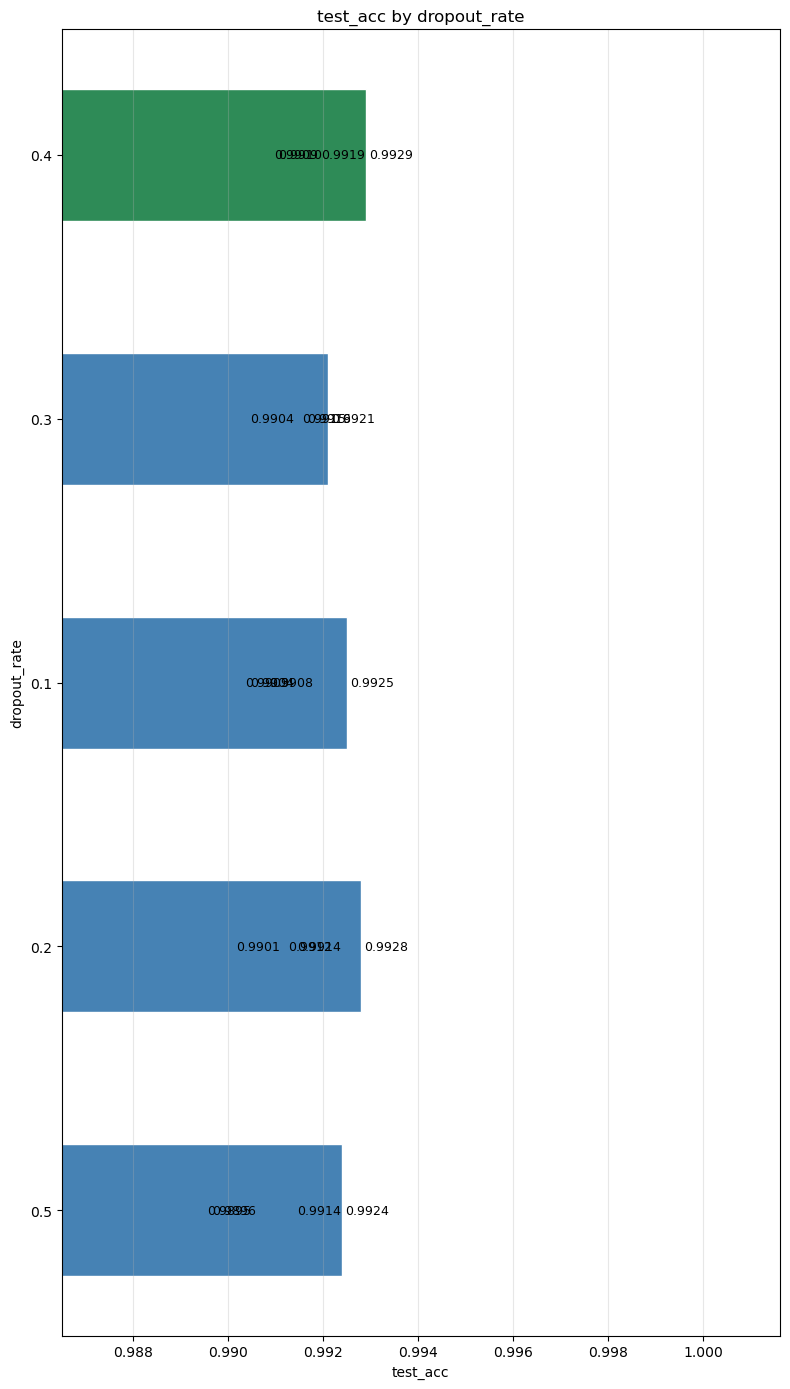


→ Beste Dropout-Rate: 0.4 mit 10 Epochs (Accuracy: 0.9929, Verbesserung zu Baseline %: 1.58%)


,method,dataset,test_loss,test_acc,trained_epochs,best_epoch,batch_size,add_dropout,dropout_rate,blocks,early_stop,model_name
0,Dropout,Standardisiert (0-1),0.030528,0.9904,5,5,128,True,0.1,2,False,model_Dropout_Standardisiert_(0-1).keras
1,Dropout,Standardisiert (0-1),0.028223,0.9901,5,5,128,True,0.2,2,False,model_Dropout_Standardisiert_(0-1).keras
2,Dropout,Standardisiert (0-1),0.028061,0.9904,5,5,128,True,0.3,2,False,model_Dropout_Standardisiert_(0-1).keras
3,Dropout,Standardisiert (0-1),0.029408,0.9909,5,5,128,True,0.4,2,False,model_Dropout_Standardisiert_(0-1).keras
4,Dropout,Standardisiert (0-1),0.031975,0.9895,5,5,128,True,0.5,2,False,model_Dropout_Standardisiert_(0-1).keras
5,Dropout,Standardisiert (0-1),0.031446,0.9903,10,5,128,True,0.1,2,False,model_Dropout_Standardisiert_(0-1).keras
6,Dropout,Standardisiert (0-1),0.024415,0.9912,10,10,128,True,0.2,2,False,model_Dropout_Standardisiert_(0-1).keras
7,Dropout,Standardisiert (0-1),0.027763,0.9915,10,9,128,True,0.3,2,False,model_Dropout_Standardisiert_(0-1).keras
8,Dropout,Standardisiert (0-1),0.025064,0.9929,10,9,128,True,0.4,2,False,model_Dropout_Standardisiert_(0-1).keras
9,Dropout,Standardisiert (0-1),0.036466,0.9896,10,8,128,True,0.5,2,False,model_Dropout_Standardisiert_(0-1).keras


In [22]:
phase4_parts    = []
phase4_histories = {}

for epochs in [5, 10, 15, 20]:
    for rate in [0.1, 0.2, 0.3, 0.4, 0.5]:
        df, hist = train_and_evaluate_models(
            {best_preprocessing: preprocessing_variants[best_preprocessing]},
            method="Dropout", batch_size=best_batch_size, epochs=epochs,
            add_dropout=True, dropout_rate=rate, blocks=best_blocks,
    )
        phase4_parts.append(df)
        phase4_histories[f"Dropout {rate}"] = hist[best_preprocessing]

phase4_results = pd.concat(phase4_parts, ignore_index=True)

plot_metric_distribution_by_group(
    phase4_results, metric_col="test_acc", group_col="dropout_rate",
    ylim=(phase4_results["test_acc"].min() - 0.003, 1.0),
)

best_row = phase4_results.loc[phase4_results["test_acc"].idxmax()]
best_dropout_rate = float(best_row["dropout_rate"])
best_dropout_acc = best_row["test_acc"]
best_epochs = int(best_row["trained_epochs"])
print(f"\n→ Beste Dropout-Rate: {best_dropout_rate} mit {best_epochs} Epochs (Accuracy: {best_dropout_acc:.4f}, Verbesserung zu Baseline %: {(best_dropout_acc - baseline_acc) / baseline_acc * 100:.2f}%)")
phase4_results

---

# Phase 5 – Augmentierung

Die beste Konfiguration aus Phase 4 (Vorverarbeitung + Blockanzahl + Dropout-Rate) wird
mit und ohne Augmentierung verglichen. Augmentierung: Shift ±3 px, Rotation ±15°.
Nur eine Entscheidung: bringt Augmentierung auf der besten Konfiguration einen Mehrwert?


In [23]:
# Augmentierte Variante der besten Vorverarbeitung dynamisch erzeugen

aug_dataset_name = f"Aug {best_preprocessing}"
x_test_best      = preprocessing_variants[best_preprocessing][2]

augmentation_comparison = {
    best_preprocessing: preprocessing_variants[best_preprocessing],
    aug_dataset_name:   (aug_preprocessing_map[best_preprocessing], y_train_aug, x_test_best, y_test),
}

print(f"Vergleiche '{best_preprocessing}' vs. '{aug_dataset_name}'...")
phase5_results, _ = train_and_evaluate_models(
    augmentation_comparison,
    method="Augmentation", batch_size=best_batch_size, epochs=10,
    add_dropout=True, dropout_rate=best_dropout_rate, blocks=best_blocks,
)
phase5_results


Vergleiche 'Standardisiert (0-1)' vs. 'Aug Standardisiert (0-1)'...
  Training: Standardisiert (0-1)


  Training: Aug Standardisiert (0-1)


,method,dataset,test_loss,test_acc,trained_epochs,best_epoch,batch_size,add_dropout,dropout_rate,blocks,early_stop,model_name
1,Augmentation,Aug Standardisiert (0-1),0.020765,0.9940,10,8,128,True,0.4,2,False,model_Augmentation_Aug_Standardisiert_(0-1).keras
0,Augmentation,Standardisiert (0-1),0.027167,0.9915,10,10,128,True,0.4,2,False,model_Augmentation_Standardisiert_(0-1).keras


In [ ]:

best_dataset_name = phase5_results.iloc[0]["dataset"]
best_dataset_acc = phase5_results.iloc[0]["test_acc"]
print(f"\n→ Beste Augmentierte Variante: '{best_dataset_name}'  (Accuracy {best_dataset_acc:.4f}, Verbesserung zu Baseline %: {(best_dataset_acc - baseline_acc) / baseline_acc * 100:.2f}%)")


→ Beste Augmentierte Variante: 'Aug Standardisiert (0-1)'  (Accuracy 0.9940, Verbesserung zu Baseline %: 1.69%)
